In `Asthma vs air qualiy` I look at how asthma outcomes are related to air quality, including the effects of demographics and spatial autocorrelation. Some of the details of the model selection process are expanded here, for completeness and transparency.
- Collinearity of predictors
- Spatial distribution of error terms in non-spatial OLS models
- Different results from different spatial weighting techniques
- Modeling spatial lag in the dependent variable aka spatial lag model

In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from libpysal.weights import Queen, KNN
from esda.moran import Moran
import spreg

from air_brain.asthma import build_dataset
from air_brain.tables import ols2df, spreg2df, p_col_style

In [2]:
df = build_dataset()
dep_vars = ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"]

# Collinearity of predictors

The four variables we want to include in our models are all very collinear with each other, except PoC, which is only moderately collinear. I'm using the variance inflation factor (VIF) with a cutoff of 5.

In [3]:
cols = ["PM25", "dpm", "lowincome", "poc"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 7.805840271300308
dpm 8.44092870162693
lowincome 10.360421525696621
poc 4.833696233666254


The high collinearity between PM 2.5 and diesel PM is expected, since diesel PM is (generally) a subset of PM 2.5.

We also observe collinearity for the models that have PM 2.5 but not diesel PM, particularly in the low income demographic variable.

In [4]:
cols = ["PM25", "lowincome", "poc"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 4.164822439358602
lowincome 9.628665545617753
poc 4.830049297361873


This collinearity isn't surprising, from a sociodemographic perspective. Furthermore, we observe in the main results that all these variables are pairwise significantly correlated with each other.

Collinearity is a barrier to deriving meaningful results from the dataset, because it inflates the standard errors of the regression models. Predictors that may in fact have an important effect on the outcomes may look insignificant because their effect is blurred from the inclusion of other highly correlated variables. There are a handful of standard ways of handling collinearity for explanatory models(*):
- Drop variables
- Combine variables, e.g. as mean or difference
- Combine variables, e.g. as PCA/factor analysis

None of these options are ideal, particularly since I have so few variables to start with. I want to keep both PM 2.5 and diesel PM for the emergency department outcomes, since I find it interesting that diesel PM is predictive of emergency outcomes but not urgent care or asthma care generally. I want to keep both low income and PoC as demographics to control for because I believe that they represent different barriers to healthcare. And I want to include both air quality and demographics, because I want to demonstrate an impact of air quality separate from the correlation of poor air quality with barriers to healthcare.

(*) I'm ignoring ridge regression because, in my understanding, assigning significance to coefficients in a ridge regression model is not considered reliable. And since the point of an explanatory regression model is to determine the importance of predictors' effects on outcomes, this difficulty makes ridge regression a non-starter.

But maybe I'm worrying for nothing! What happens when I run the regressions with all variables, ignoring the collinearity?

In [5]:
demo_vars = ["lowincome", "poc"]
indep_to_use = {"ED_visits_frac": ["PM25", "dpm"],
                "ED_hosp_frac": ["PM25", "dpm"],
                "UC_visits_frac": ["PM25"],
                "Asthma_use_frac": ["PM25"]}

In [6]:
# linear regression, predicting asthma encounter fraction using air quality as well as demographics,
# including all variables
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[indep_to_use[col] + demo_vars + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

Without the demographics, all four of these outcomes had their associated air quality measures as significant predictors. With both demographics, PM 2.5 is only a significant predictor of urgent care and general asthma use, and neither air quality measure is predictive of emergency department care. However, both demographics are significant predictors of emergency department care, and PoC is predictive of general asthma care.

With the collinearities among the variables, I'm not sure if the losses of significance in the air quality variables are a real reflection of the relationships among these variables, or whether they are due to variance inflation. 

My primary question is whether air quality predicts asthma outcomes, even when controlling for demographics and spatial autocorrelation. I am interested in the differences between PM 2.5 and diesel PM, as well as the differences between PoC and low income. However, the high degree of collinearity in my relatively small dataset means that I will struggle to interpret the results of regressions using all four variables. Therefore, the best way forward is to combine the air quality measures into a single variable, and the demographic measures into another single variable. This method will still allow me to control for demographics while being able to trust negative results.

### Combining predictors

The most obvious ways to combine the variables are
- maximum
- sum or mean
- taking the first component of PCA

It's not immediately obvious which way of combining predictors is best, or whether it may differ by predictor or dependent variable. Without a theoretical justification for any of these, I will look to the data and pick the combination method that results in a variable that maximizes the coefficient of determination R2. This choice argues that the best way of combining variables is the one that is most predictive of the outcome.

In [7]:
# scale PM 2.5 and diesel before combining, because they are on very different scales
df[["PM25_scale", "dpm_scale"]] = StandardScaler().fit_transform(df[["PM25", "dpm"]])
df["PM25_dpm_max"] = df[["PM25_scale", "dpm_scale"]].max(axis=1)
df["PM25_dpm_mean"] = df[["PM25_scale", "dpm_scale"]].mean(axis=1)

# only use combined variable for ED outcomes, because only PM 2.5 was significant for non-ED outcomes
indep_to_use_max = {"ED_visits_frac": ["PM25_dpm_max"],
                    "ED_hosp_frac": ["PM25_dpm_max"],
                    "UC_visits_frac": ["PM25"],
                    "Asthma_use_frac": ["PM25"]}
indep_to_use_mean = {"ED_visits_frac": ["PM25_dpm_mean"],
                     "ED_hosp_frac": ["PM25_dpm_mean"],
                     "UC_visits_frac": ["PM25"],
                     "Asthma_use_frac": ["PM25"]}

# PoC and lowincome are naturally on the same scale, so don't need to re-scale
df["poc_lowincome_max"] = df[["poc", "lowincome"]].max(axis=1)
df["poc_lowincome_mean"] = df[["poc", "lowincome"]].mean(axis=1)

# compute PCA as well
pca_air = PCA(n_components=1)
pca_air.fit(df[["PM25", "dpm"]])
print("Air quality PCA explained variance:  {}".format(pca_air.explained_variance_ratio_[0].round(3)))
df["PM25_dpm_pca"] = pca_air.transform(df[["PM25", "dpm"]])

pca_demo = PCA(n_components=1)
pca_demo.fit(df[["lowincome", "poc"]])
print("Demographics PCA explained variance: {}".format(pca_demo.explained_variance_ratio_[0].round(3)))
df["poc_lowincome_pca"] = pca_demo.transform(df[["lowincome", "poc"]])

Air quality PCA explained variance:  0.894
Demographics PCA explained variance: 0.896


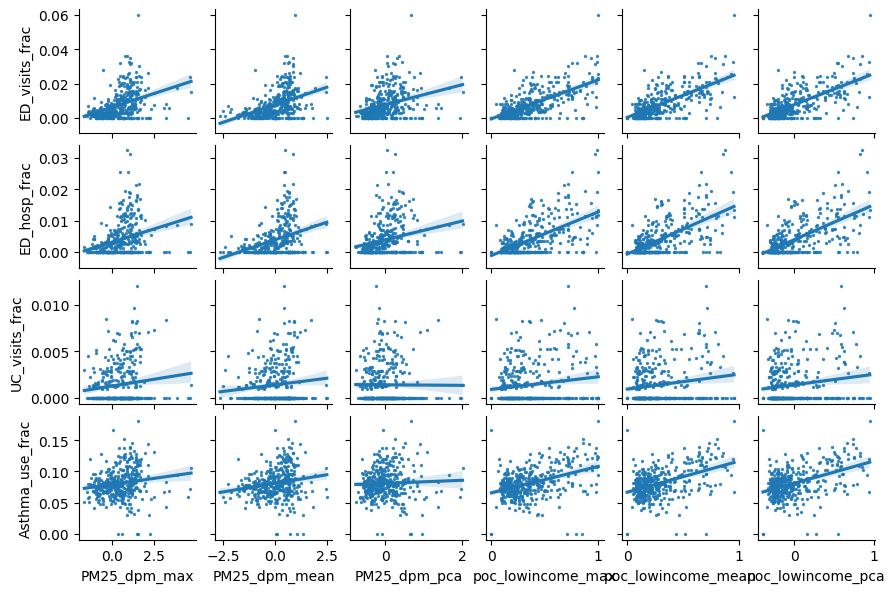

In [8]:
import seaborn as sns
sns.pairplot(df[["PM25_dpm_max", "PM25_dpm_mean", "PM25_dpm_pca", "poc_lowincome_max", "poc_lowincome_mean", "poc_lowincome_pca"] + dep_vars],
             x_vars=["PM25_dpm_max", "PM25_dpm_mean", "PM25_dpm_pca", "poc_lowincome_max", "poc_lowincome_mean", "poc_lowincome_pca"], 
             y_vars=dep_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

In [9]:
combo_vars = {"PM25_dpm_max": ["ED_visits_frac", "ED_hosp_frac"],
              "PM25_dpm_mean": ["ED_visits_frac", "ED_hosp_frac"],
              "PM25_dpm_pca": ["ED_visits_frac", "ED_hosp_frac"],
              "poc_lowincome_max": ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"],
              "poc_lowincome_mean": ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"],
              "poc_lowincome_pca": ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"],
             }

all_res = list()
for indep in combo_vars:
    ols_res = dict()
    for dep in combo_vars[indep]:
        mod = sm.OLS(df[dep], df[[indep] + ["intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
pd.concat(all_res).sort_values(["dep_var", "R2"]).style.pipe(p_col_style)

These results suggest that I should use the mean to combine air quality measures, and PCA to combine demographics.

I find this conclusion odd. Using the first principal component is essentially using a weighted average of the two variables. I would expect PCA to always generate better results than a simple average, because it better accounts for the relationships between the variables.

In [10]:
combo_indep_vars = {"ED_visits_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "ED_hosp_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "UC_visits_frac": ["PM25", "poc_lowincome_pca"],
                    "Asthma_use_frac": ["PM25", "poc_lowincome_pca"]}

In [11]:
cols = ["PM25_dpm_mean", "poc_lowincome_pca"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25_dpm_mean 1.3891119112222916
poc_lowincome_pca 1.3891119112222916


In [12]:
cols = ["PM25", "poc_lowincome_pca"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 1.0000446674570382
poc_lowincome_pca 1.0000446674570382


In [13]:
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[combo_indep_vars[col] + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

# Spatial distribution of error term

In [14]:
# linear regression, predicting asthma encounter fraction using average PM 2.5 concentration as sole predictor
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[["PM25"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

,,coef,std err,p
dep_var,indep_var,,,
ED_visits_frac,PM25,0.000740,0.000038,0.000
ED_hosp_frac,PM25,0.000370,0.000026,0.000
UC_visits_frac,PM25,0.000132,0.000010,0.000
Asthma_use_frac,PM25,0.007687,0.000115,0.000


<Axes: >

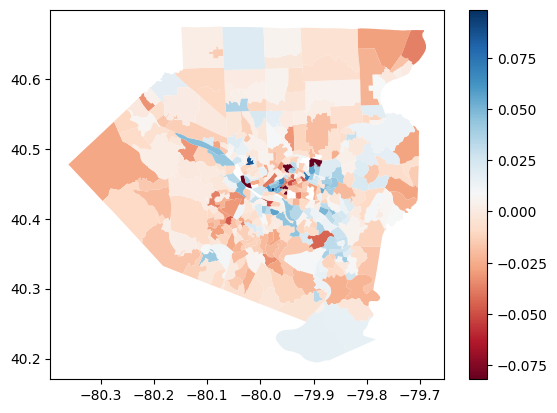

In [15]:
r_df = pd.concat([df, ols_res["Asthma_use_frac"].resid], axis=1)
r_df.plot(0, legend=True, cmap="RdBu")

In [16]:
# spatial lag weights from Queen's contiguity
w = Queen.from_dataframe(df, use_index=False)
# standardize by rows
w.transform = "R"

In [17]:
moran = Moran(r_df[0], w)
moran.p_sim

np.float64(0.001)

In [18]:
# start without controlling for demographics
indep = ["PM25"]
res_dict = dict()
for dep in dep_vars:
    res = spreg.GM_Error_Het(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict)[["coef", "std err", "p"]].style.pipe(p_col_style)

<Axes: >

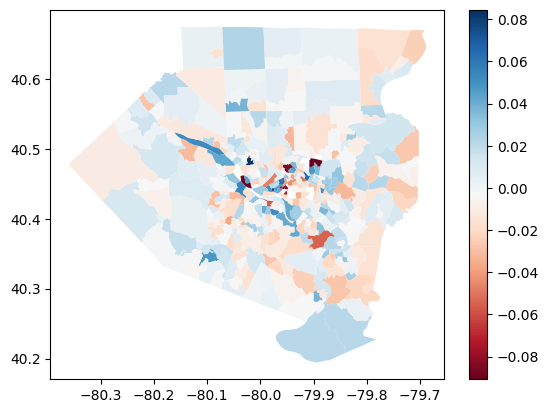

In [19]:
residuals = res_dict['Asthma_use_frac'].e_filtered
r_df = df.copy()
r_df['resid'] = residuals
r_df.plot('resid', legend=True, cmap="RdBu")

# Spatial lag of the outcomes

In [20]:
# Spatial lag in the dependent variable, fit using
# general method of moments estimation allowing for dependent variable lag
#
# This is a general method that allows us to choose the weights used to lag the dependent variable,
# in this case the same spatial lag weights computed above
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep]
    res = spreg.GM_Lag(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict, name_attr="name_z")[["coef", "std err", "p"]].style.pipe(p_col_style)